# Drug Condition Classification — BioBERT

This notebook fine-tunes BioBERT to classify patient drug reviews into one of **17 medical conditions** (merged from the original 20 to resolve label ambiguity).

**Model:** `dmis-lab/biobert-base-cased-v1.2`  
BioBERT is BERT pretrained further on ~18 billion words of biomedical text (PubMed abstracts + PMC full texts), making it well-suited for medical text classification.

**Label merges applied:**
- `Obesity` + `Weight Loss` → `Obesity/Weight Loss`
- `Depression` + `Major Depressive Disorder` → `Depression`
- `Anxiety` + `Anxiety and Stress` → `Anxiety`

**GPU required** — Enable in Colab: Runtime → Change runtime type → T4 GPU

## 0. Setup

In [10]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/nlp-project'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install transformers datasets torch scikit-learn --quiet

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import html
import time

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from datasets import Dataset
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
if device == 'cpu':
    print('WARNING: No GPU detected. Enable GPU in Colab: Runtime → Change runtime type → T4 GPU')

Using device: cuda


## 1. Load Data

In [ ]:
train_df = pd.read_csv(f'{DRIVE_PATH}/archive/drugsComTrain_raw.csv')
test_df  = pd.read_csv(f'{DRIVE_PATH}/archive/drugsComTest_raw.csv')

# Merged conditions: ambiguous label pairs collapsed into single classes
# - Obesity + Weight Loss     → "Obesity/Weight Loss"  (same condition, indistinguishable language)
# - Depression + Major Depressive Disorder → "Depression"  (different granularity, same diagnosis)
# - Anxiety + Anxiety and Stress → "Anxiety"  (same experience, inconsistent labeling)
LABEL_MAP = {
    'Weight Loss':              'Obesity/Weight Loss',
    'Obesity':                  'Obesity/Weight Loss',
    'Major Depressive Disorde': 'Depression',
    'Anxiety and Stress':       'Anxiety',
}

CONDITIONS = [
    'Birth Control', 'Depression', 'Pain', 'Anxiety', 'Acne',
    'Bipolar Disorde', 'Insomnia', 'Obesity/Weight Loss', 'ADHD',
    'Emergency Contraception', 'High Blood Pressure', 'Vaginal Yeast Infection',
    'Abnormal Uterine Bleeding', 'Bowel Preparation', 'ibromyalgia',
    'Smoking Cessation', 'Migraine'
]

with open(f'{DRIVE_PATH}/top20_conditions.json', 'w') as f:
    json.dump(CONDITIONS, f, indent=2)

print(f'Train size: {len(train_df):,}')
print(f'Test size:  {len(test_df):,}')
print(f'Conditions ({len(CONDITIONS)}): {CONDITIONS}')

## 2. Preprocessing

**Note:** BioBERT is cased — we do NOT lowercase the text. Capitalization carries meaning in medical text (e.g., drug names like `Prozac` vs `prozac`).

In [ ]:
def preprocess(df, conditions, label_map):
    # Apply label merging before filtering
    df = df.copy()
    df['condition'] = df['condition'].replace(label_map)
    # Keep only rows whose condition is in the final conditions list
    df = df[df['condition'].isin(conditions)].copy()
    # Decode HTML entities (&#039; → ', &amp; → &, etc.)
    df['review_clean'] = df['review'].apply(html.unescape)
    # Strip surrounding quote marks left over from CSV encoding
    df['review_clean'] = df['review_clean'].str.strip('"').str.strip()
    # Encode condition names as integer labels
    df['label'] = pd.Categorical(df['condition'], categories=conditions).codes
    return df[['review_clean', 'label', 'condition']].reset_index(drop=True)

train = preprocess(train_df, CONDITIONS, LABEL_MAP)
test  = preprocess(test_df,  CONDITIONS, LABEL_MAP)

print(f'Train size after filtering: {len(train):,}')
print(f'Test size after filtering:  {len(test):,}')
print(f'Number of classes: {len(CONDITIONS)}')
print()
print('Class distribution (train):')
print(train['condition'].value_counts())

## 3. Tokenization

In [14]:
MODEL_NAME = 'dmis-lab/biobert-base-cased-v1.2'
MAX_LEN = 256

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch['review_clean'],
        truncation=True,
        padding='max_length',
        max_length=MAX_LEN
    )

# Convert pandas DataFrames to HuggingFace Dataset format
train_hf = Dataset.from_pandas(train[['review_clean', 'label']])
test_hf  = Dataset.from_pandas(test[['review_clean', 'label']])

print('Tokenizing training set...')
train_hf = train_hf.map(tokenize, batched=True, batch_size=512)
print('Tokenizing test set...')
test_hf  = test_hf.map(tokenize,  batched=True, batch_size=512)

train_hf.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
test_hf.set_format('torch',  columns=['input_ids', 'attention_mask', 'label'])

print('Tokenization complete.')
print(f'Input shape: {train_hf[0]["input_ids"].shape}')

Tokenizing training set...


Map:   0%|          | 0/93499 [00:00<?, ? examples/s]

Tokenizing test set...


Map:   0%|          | 0/31399 [00:00<?, ? examples/s]

Tokenization complete.
Input shape: torch.Size([256])


## 4. Load Model

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(CONDITIONS)
)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model: {MODEL_NAME}')
print(f'Total parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

## 5. Metrics

In [16]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds    = np.argmax(logits, axis=-1)
    acc      = accuracy_score(labels, preds)
    macro_f1 = f1_score(labels, preds, average='macro')
    return {'accuracy': acc, 'f1': macro_f1}

## 6. Training

In [17]:
training_args = TrainingArguments(
    output_dir=f'{DRIVE_PATH}/biobert_checkpoints',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    logging_steps=100,
    fp16=(device == 'cuda'),
    report_to='none'
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_hf,
    eval_dataset=test_hf,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)] # if F1 doesn't improve for 2 consecutive epochs the training will be stopped instead of waiting for epoch 3
)

print('Starting BioBERT fine-tuning...')
print(f'Training on {len(train_hf):,} samples for up to 3 epochs')
t0 = time.time()
trainer.train()
train_time = time.time() - t0
print(f'\nTraining complete in {train_time/60:.1f} minutes')

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Starting BioBERT fine-tuning...
Training on 93,499 samples for up to 3 epochs


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.458624,0.452963,0.848052,0.788706
2,0.343702,0.379598,0.875410,0.822745
3,0.248396,0.358894,0.890602,0.846845


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Training complete in 70.7 minutes


## 7. Evaluation

In [ ]:
predictions  = trainer.predict(test_hf)
y_pred       = np.argmax(predictions.predictions, axis=-1)
y_true       = test['label'].values
label_names  = CONDITIONS

acc          = accuracy_score(y_true, y_pred)
macro_f1     = f1_score(y_true, y_pred, average='macro')
weighted_f1  = f1_score(y_true, y_pred, average='weighted')
per_class_f1 = f1_score(y_true, y_pred, average=None)

print('=== BioBERT RESULTS ===')
print(f'Accuracy:     {acc*100:.2f}%')
print(f'Macro F1:     {macro_f1*100:.2f}%')
print(f'Weighted F1:  {weighted_f1*100:.2f}%')
print(f'Train time:   {train_time/60:.1f} min')

print('\n=== PER-CLASS REPORT ===')
print(classification_report(y_true, y_pred, target_names=label_names))

## 8. Training Curves

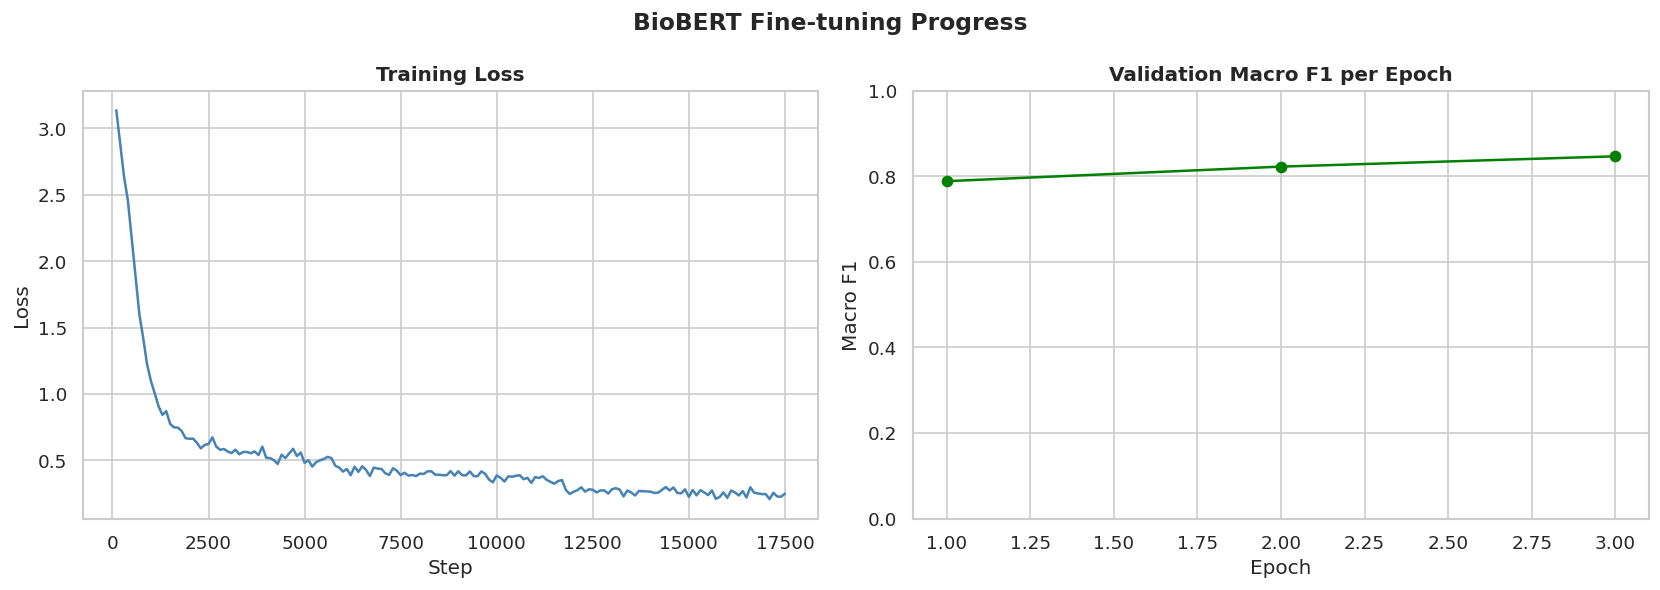

Saved: biobert_training_curves.png


In [19]:
log_history  = trainer.state.log_history
train_losses = [(e['step'], e['loss']) for e in log_history if 'loss' in e and 'eval_loss' not in e]
eval_results = [(e['epoch'], e['eval_f1']) for e in log_history if 'eval_f1' in e]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if train_losses:
    steps, losses = zip(*train_losses)
    axes[0].plot(steps, losses, color='steelblue')
    axes[0].set_xlabel('Step')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training Loss', fontweight='bold')

if eval_results:
    epochs, f1s = zip(*eval_results)
    axes[1].plot(epochs, f1s, marker='o', color='green')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Macro F1')
    axes[1].set_title('Validation Macro F1 per Epoch', fontweight='bold')
    axes[1].set_ylim(0, 1)

plt.suptitle('BioBERT Fine-tuning Progress', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/biobert_training_curves.png', bbox_inches='tight')
plt.show()
print('Saved: biobert_training_curves.png')

## 9. Confusion Matrix

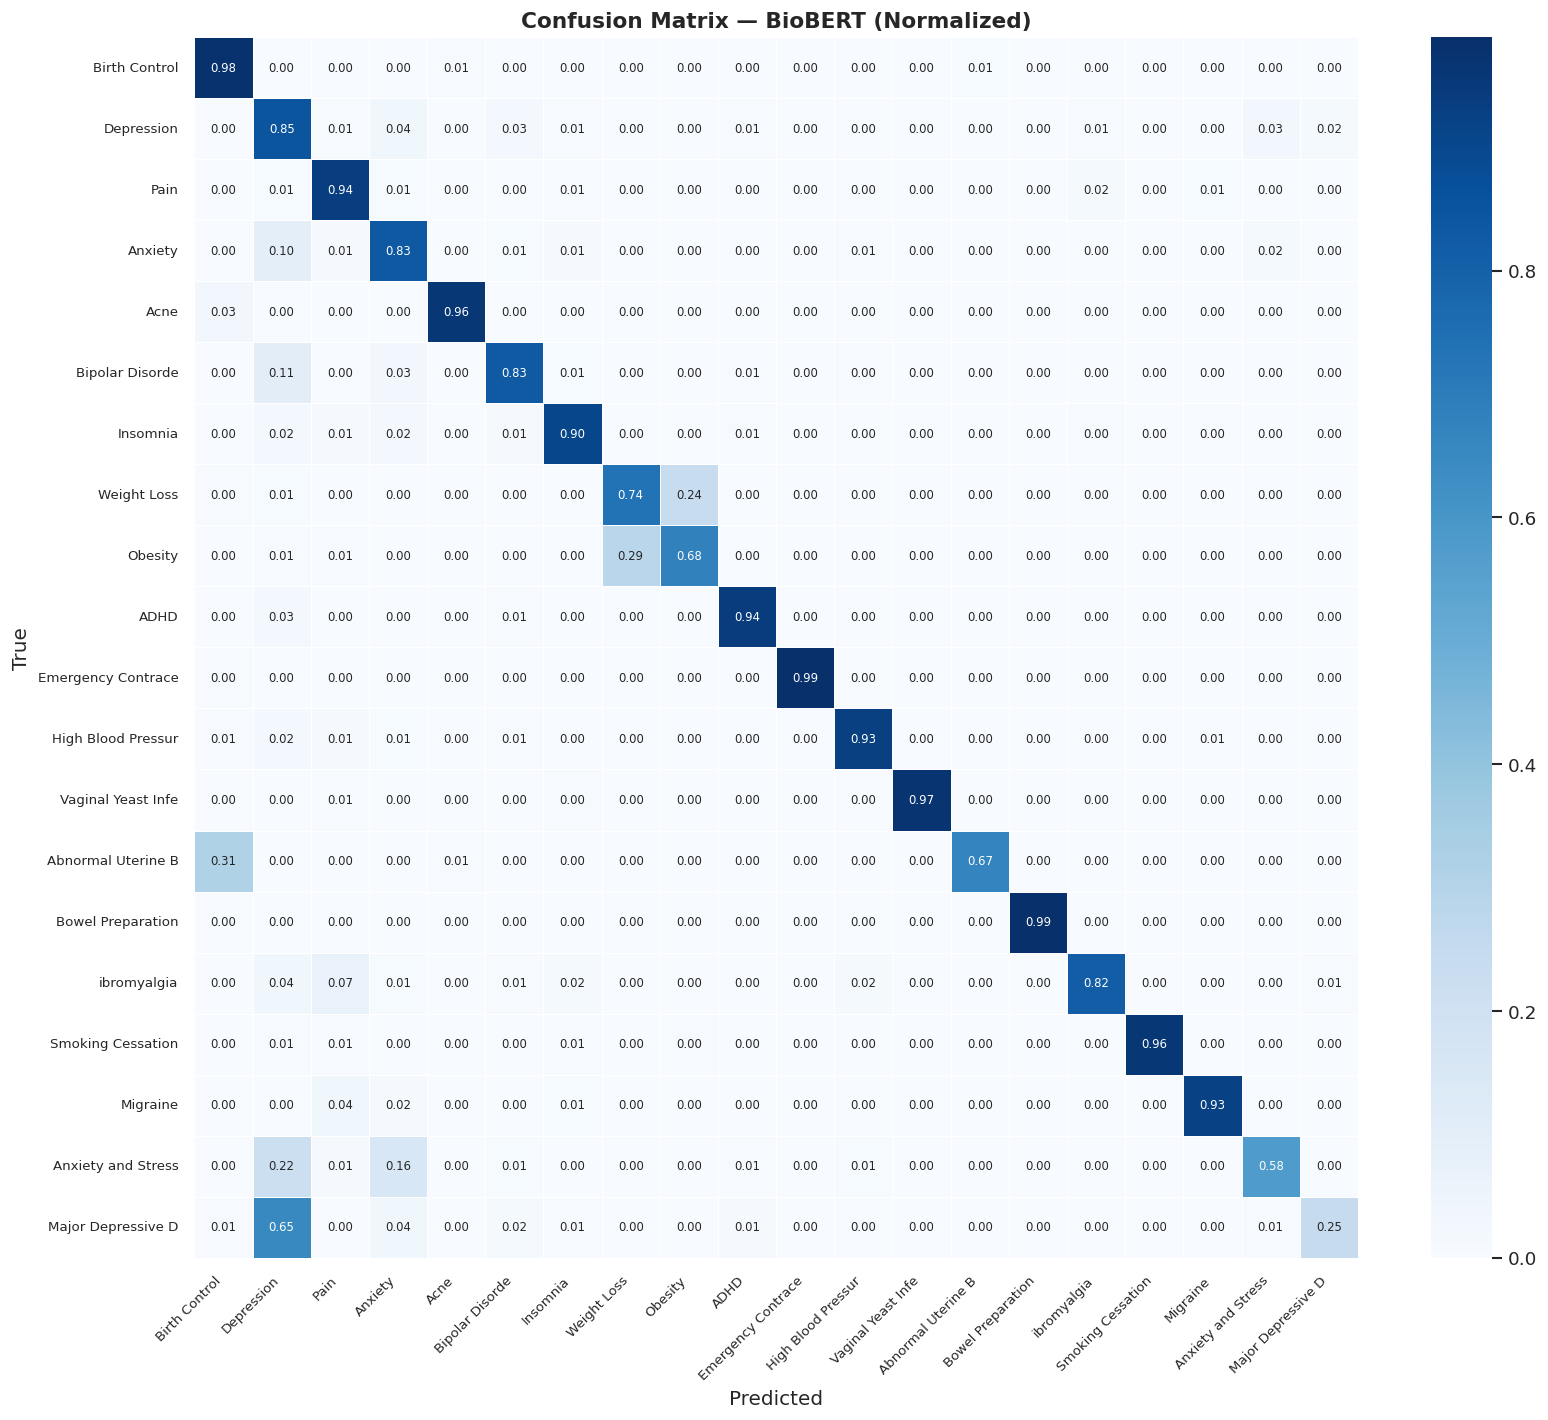

Saved: biobert_confusion_matrix.png


In [20]:
cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
short_names = [c[:18] for c in label_names]

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=short_names, yticklabels=short_names,
            linewidths=0.5, ax=ax, annot_kws={'size': 7})
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title('Confusion Matrix — BioBERT (Normalized)', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/biobert_confusion_matrix.png', bbox_inches='tight')
plt.show()
print('Saved: biobert_confusion_matrix.png')

## 10. Per-Class F1 Chart

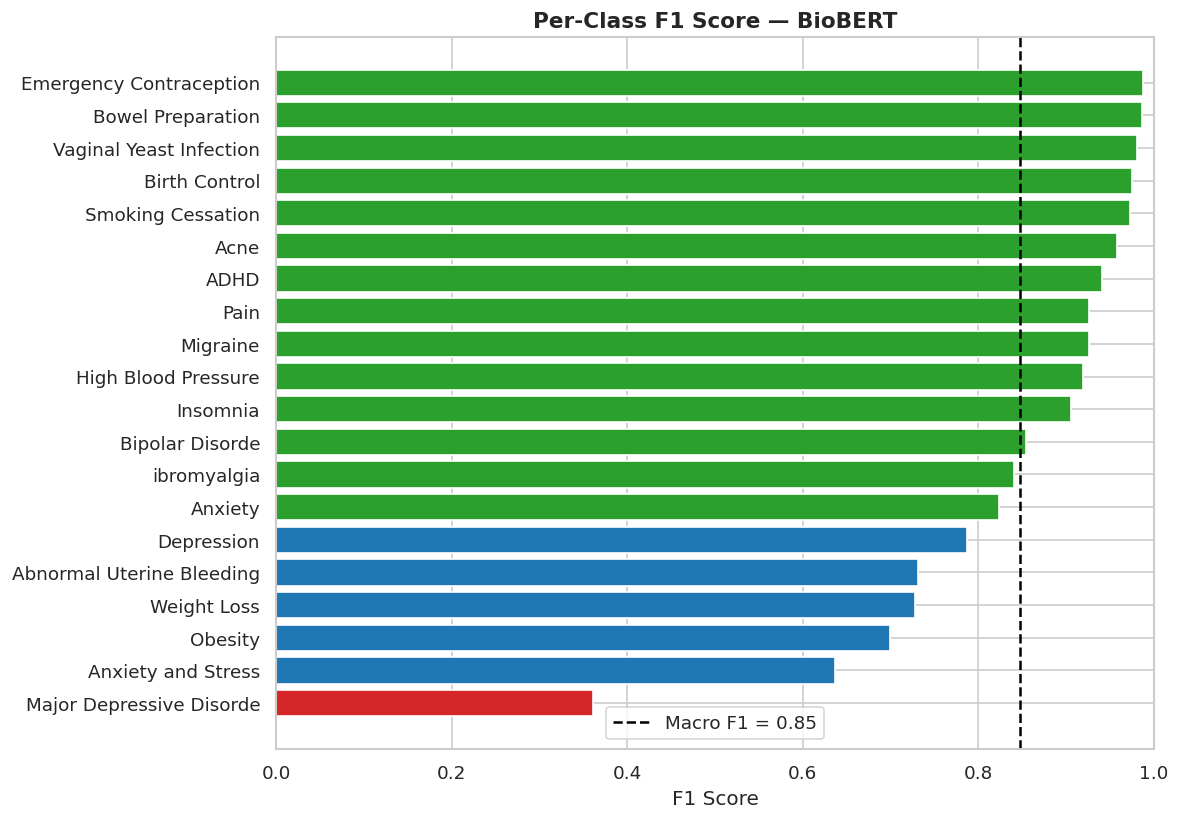

Saved: biobert_per_class_f1.png


In [21]:
f1_series = pd.Series(per_class_f1, index=label_names).sort_values()
colors = ['#d62728' if v < 0.6 else '#2ca02c' if v > 0.8 else '#1f77b4' for v in f1_series.values]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(f1_series.index, f1_series.values, color=colors)
ax.axvline(x=macro_f1, color='black', linestyle='--', label=f'Macro F1 = {macro_f1:.2f}')
ax.set_xlabel('F1 Score')
ax.set_title('Per-Class F1 Score — BioBERT', fontsize=13, fontweight='bold')
ax.legend()
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/biobert_per_class_f1.png', bbox_inches='tight')
plt.show()
print('Saved: biobert_per_class_f1.png')

## 11. Error Analysis

Look at examples the model got wrong to understand its failure modes.

In [ ]:
test['predicted'] = y_pred
test['predicted_condition'] = [CONDITIONS[p] for p in y_pred]
test['correct'] = test['label'] == test['predicted']

wrong = test[~test['correct']]
print(f'Total misclassified: {len(wrong):,} / {len(test):,} ({len(wrong)/len(test)*100:.1f}%)')
print()

# Most common confusion pairs
print('Most common confusion pairs (True → Predicted):')
confusion_pairs = wrong.groupby(['condition', 'predicted_condition']).size().sort_values(ascending=False).head(10)
print(confusion_pairs.to_string())

In [23]:
# Show 3 example misclassified reviews
print('Example misclassified reviews:\n')
for _, row in wrong.head(3).iterrows():
    print(f'True condition:      {row["condition"]}')
    print(f'Predicted condition: {row["predicted_condition"]}')
    print(f'Review: {row["review_clean"][:300]}...')
    print('-' * 60)

Example misclassified reviews:

True condition:      Weight Loss
Predicted condition: Obesity
Review: Contrave combines drugs that were used for alcohol, smoking, and opioid cessation. People lose weight on it because it also helps control over-eating. I have no doubt that most obesity is caused from sugar/carb addiction, which is just as powerful as any drug. I have been taking it for five days, an...
------------------------------------------------------------
True condition:      Acne
Predicted condition: Birth Control
Review: So I was on Ginanvi for about 3 months before I switched over to this pill due to the high cost of Ginavi (I don't have insurance). Ginanvi had cleared up my acne in the short time I used and I was hoping this birth control would not mess that up. I was wrong. After 2-3 months of using this pill my ...
------------------------------------------------------------
True condition:      Bipolar Disorde
Predicted condition: Anxiety
Review: This medication helped me

## 12. Save Results

In [ ]:
results = {
    'model': 'BioBERT (dmis-lab/biobert-base-cased-v1.2)',
    'accuracy': round(acc, 4),
    'macro_f1': round(macro_f1, 4),
    'weighted_f1': round(weighted_f1, 4),
    'train_time_min': round(train_time / 60, 1),
    'num_classes': len(CONDITIONS),
    'train_samples': len(train),
    'test_samples': len(test),
    'per_class_f1': {label_names[i]: round(v, 4) for i, v in enumerate(per_class_f1)}
}

with open(f'{DRIVE_PATH}/results_biobert.json', 'w') as f:
    json.dump(results, f, indent=2)

print('Saved: results_biobert.json')
print()
print('=== FINAL SUMMARY ===')
print(f'Model:       {results["model"]}')
print(f'Accuracy:    {results["accuracy"]*100:.2f}%')
print(f'Macro F1:    {results["macro_f1"]*100:.2f}%')
print(f'Weighted F1: {results["weighted_f1"]*100:.2f}%')
print(f'Train time:  {results["train_time_min"]} min')

## Summary

**What we did:**
- Fine-tuned BioBERT (`dmis-lab/biobert-base-cased-v1.2`) on ~93K patient drug reviews
- Classified reviews into one of **17 medical conditions** (merged from original 20)
- Evaluated using accuracy, macro F1, and per-class F1

**Label merges:**
Three ambiguous label pairs were merged based on clinical equivalence and linguistic indistinguishability:
- `Obesity` + `Weight Loss` → `Obesity/Weight Loss`
- `Depression` + `Major Depressive Disorder` → `Depression`
- `Anxiety` + `Anxiety and Stress` → `Anxiety`

**Why BioBERT:**
- Pretrained on 18B words of biomedical text (PubMed + PMC)
- Understands medical terminology, drug names, and clinical language out of the box
- Outperforms general-purpose models on biomedical NLP tasks

**Output files saved to Google Drive:**
- `biobert_training_curves.png` — loss and F1 over epochs
- `biobert_confusion_matrix.png` — normalized confusion matrix
- `biobert_per_class_f1.png` — F1 score per condition
- `results_biobert.json` — all metrics